In [1]:
# ! pip install seaborn

# Задание 6.  Анализ формы распределений и нормализация данных

## Цели задания
* оценивать форму распределений числовых признаков с помощью асимметрии, эксцесса и коэффициента вариации,
* принимать обоснованные решения о необходимости нормализации/трансформации,
* применять подходящие методы нормализации 
* визуализировать исходные и преобразованные распределения с помощью Plotly.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import plotly
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [3]:
data = pd.read_csv('../TestData/Task6_bmw.csv')

## 1.	Общая характеристика данных

In [4]:
print(data.shape)
rows = data.shape[0]
cols = data.shape[1]
data.head(5)

(10781, 9)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [5]:
data.sample(5)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
460,2 Series,2019,21000,Semi-Auto,2380,Petrol,145,40.9,1.5
8465,X1,2016,16595,Manual,25913,Diesel,125,58.9,2.0
4336,1 Series,2019,19250,Semi-Auto,5298,Diesel,145,67.3,2.0
3411,X5,2017,32990,Automatic,31500,Diesel,145,47.1,3.0
1432,2 Series,2019,21858,Manual,123,Diesel,145,61.4,2.0


In [6]:
data.columns.tolist()

['model',
 'year',
 'price',
 'transmission',
 'mileage',
 'fuelType',
 'tax',
 'mpg',
 'engineSize']

Видим, что датасет содержит следующие столбцы

| Колонка         | Тип     | Описание                                                                 |
|-----------------|---------|--------------------------------------------------------------------------|
| model           | string  | Модель автомобиля BMW                                                    |
| year            | integer | Год выпуска                                                              |
| price           | integer | Цена автомобиля по объявлению                                            |
| transmission    | categorical (string) | Тип коробки передач (например, автоматическая, механическая)             |
| mileage         | integer | Пробег (пройденное расстояние)                                           |
| fuelType        | categorical (string)  | Тип используемого топлива (например, бензин, дизель, гибрид, электрический) |
| tax             | integer | Сумма дорожного налога                                                   |
| mpg             | float   | Экономия топлива (миль на галлон)                                        |
| engineSize      | float   | Объем двигателя в литрах                                                 |


In [7]:
# --- Определяем числовые анализируемые признаки ---
ignoring_cols = {'model', 'year'}

categorical_cols = {'transmission', 'fuelType'}

numeric_cols = (set(data.columns.tolist()) - categorical_cols) - ignoring_cols

categorical_cols = list(categorical_cols)
numeric_cols = list(numeric_cols)
print(numeric_cols)

['mpg', 'mileage', 'engineSize', 'price', 'tax']


## 2.	Анализ пропусков

In [8]:
data.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [9]:
hidden_nulls = ["", " ", "?", "N/A", "NA", "None", "Other"]

data.isin(hidden_nulls).sum()

model            0
year             0
price            0
transmission     0
mileage          0
fuelType        36
tax              0
mpg              0
engineSize       0
dtype: int64

In [10]:
(data[numeric_cols] <= .0).sum()

mpg             0
mileage         0
engineSize     47
price           0
tax           340
dtype: int64

Устранение пропусков не требуется, но чтобы алгоритмы нормализации работали корректно предлагаю заменить нули на очень близкие к ним константы

In [11]:
epsilon = 1e-6  # очень маленькое число
data[['engineSize', 'tax']] = data[['engineSize', 'tax']].replace(0, epsilon)

## 3.	Анализ исходных распределений

In [12]:
# Часть 1. Анализ исходных распределений
# Создаем DataFrame для хранения статистик
stats_list = []

for col in numeric_cols:
    # Убираем пропущенные значения для анализа
    data_clean = data[col].dropna()
    
    # Основные статистики
    mean_val = data_clean.mean()
    median_val = data_clean.median()
    
    # Мода - берем первое значение, если несколько
    mode_result = stats.mode(data_clean, keepdims=False)
    mode_val = mode_result.mode if mode_result.count > 1 else np.nan
    
    std_val = data_clean.std()
    skew_val = stats.skew(data_clean)
    kurtosis_val = stats.kurtosis(data_clean, fisher=True)  # избыточный эксцесс
    cv_val = std_val / mean_val if mean_val != 0 else np.nan  # коэффициент вариации
    
    # Сохраняем результаты
    stats_list.append({
        'Признак': col,
        'Среднее': mean_val,
        'Медиана': median_val,
        'Мода': mode_val,
        'Ст. отклонение': std_val,
        'Асимметрия': skew_val,
        'Эксцесс': kurtosis_val,
        'Коэф. вариации': cv_val
    })

# Создаем DataFrame с результатами
stats_df = pd.DataFrame(stats_list)

# Форматируем вывод для лучшей читаемости
pd.set_option('display.float_format', '{:.3f}'.format)

# Выводим таблицу со статистиками
print("Статистики числовых признаков:")
display(stats_df)

Статистики числовых признаков:


,Признак,Среднее,Медиана,Мода,Ст. отклонение,Асимметрия,Эксцесс,Коэф. вариации
0,mpg,56.399,53.300,65.700,31.337,9.628,120.403,0.556
1,mileage,25496.987,18347.000,123.000,25143.193,1.383,2.224,0.986
2,engineSize,2.168,2.000,2.000,0.552,0.851,2.437,0.255
3,price,22733.409,20462.000,20980.000,11415.528,1.587,4.019,0.502
4,tax,131.702,145.000,145.000,61.511,0.828,9.254,0.467


In [13]:
# Классификация асимметрии
print("\nКлассификация асимметрии:")
stats_df['Уровень асимметрии'] = pd.cut(
    stats_df['Асимметрия'].abs(),
    bins=[0, 0.5, 1, float('inf')],
    labels=['Незначительная', 'Умеренная', 'Выраженная'],
    right=False
)
display(stats_df[['Признак', 'Асимметрия', 'Уровень асимметрии']])

# Классификация эксцесса
print("\nКлассификация эксцесса:")
stats_df['Тип эксцесса'] = pd.cut(
    stats_df['Эксцесс'],
    bins=[0, 2.5, 3.5, float('inf')],
    labels=['Платикуртическое (плоское)', 'Мезокуртическое (нормальное)', 'Лептокуртическое (острое)']
)
display(stats_df[['Признак', 'Эксцесс', 'Тип эксцесса']])

# Ранжирование по коэффициенту вариации
print("\nРанжирование признаков по вариативности (коэффициент вариации):")
cv_sorted = stats_df[['Признак', 'Коэф. вариации']].sort_values('Коэф. вариации', ascending=False)
display(cv_sorted)


Классификация асимметрии:


,Признак,Асимметрия,Уровень асимметрии
0,mpg,9.628,Выраженная
1,mileage,1.383,Выраженная
2,engineSize,0.851,Умеренная
3,price,1.587,Выраженная
4,tax,0.828,Умеренная



Классификация эксцесса:


,Признак,Эксцесс,Тип эксцесса
0,mpg,120.403,Лептокуртическое (острое)
1,mileage,2.224,Платикуртическое (плоское)
2,engineSize,2.437,Платикуртическое (плоское)
3,price,4.019,Лептокуртическое (острое)
4,tax,9.254,Лептокуртическое (острое)



Ранжирование признаков по вариативности (коэффициент вариации):


,Признак,Коэф. вариации
1,mileage,0.986
0,mpg,0.556
3,price,0.502
4,tax,0.467
2,engineSize,0.255


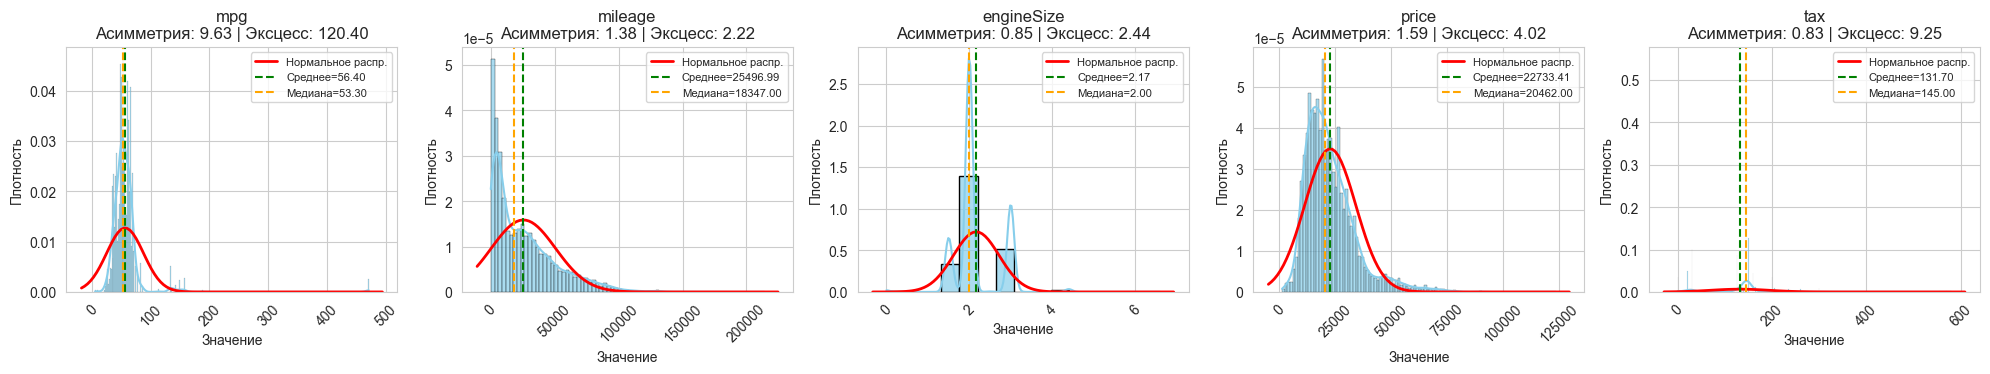

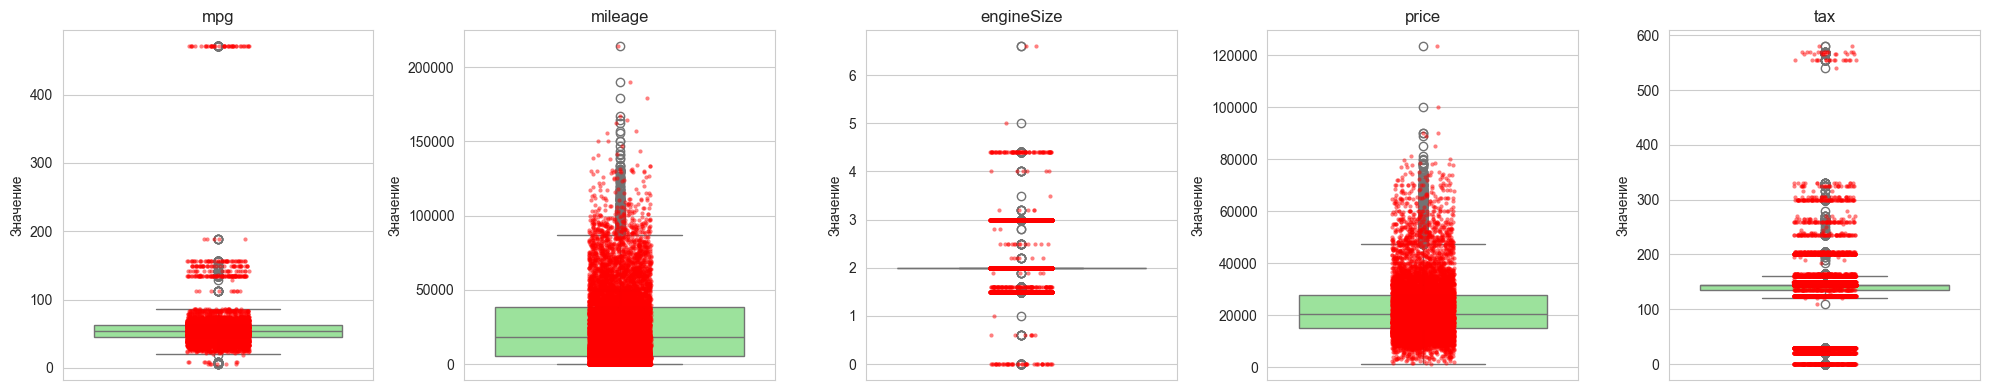

In [14]:
# Настройки визуализации
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 4)  # Широкий график для 5 признаков
plt.rcParams['font.size'] = 10

# Создаем фигуру с 5 subplots в одной строке
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))

# Построение графиков для каждого признака
for i, col in enumerate(numeric_cols):
    # Очищаем данные от пропусков
    data_clean = data[col].dropna()
    
    # Гистограмма с KDE
    sns.histplot(data_clean, kde=True, ax=axes[i], stat='density', 
                 color='skyblue', edgecolor='black', alpha=0.7)
    
    # Добавляем нормальное распределение для сравнения
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    if len(data_clean) > 1:
        # Теоретическое нормальное распределение с теми же параметрами
        p = stats.norm.pdf(x, data_clean.mean(), data_clean.std())
        axes[i].plot(x, p, 'r', linewidth=2, label='Нормальное распр.')
    
    # Вертикальные линии для среднего и медианы
    axes[i].axvline(data_clean.mean(), color='green', linestyle='--', 
                    linewidth=1.5, label=f'Среднее={data_clean.mean():.2f}')
    axes[i].axvline(data_clean.median(), color='orange', linestyle='--', 
                    linewidth=1.5, label=f'Медиана={data_clean.median():.2f}')
    
    # Настройки графика
    axes[i].set_title(f'{col}\nАсимметрия: {stats.skew(data_clean):.2f} | Эксцесс: {stats.kurtosis(data_clean, fisher=True):.2f}')
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Плотность')
    axes[i].legend(fontsize=8, loc='upper right')
    
    # Поворачиваем подписи на оси X если нужно
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Дополнительно: Boxplot для всех признаков
fig2, axes2 = plt.subplots(1, len(numeric_cols), figsize=(20, 4))

for i, col in enumerate(numeric_cols):
    data_clean = data[col].dropna()
    
    # Boxplot
    sns.boxplot(y=data_clean, ax=axes2[i], color='lightgreen')
    
    # Добавляем точки для выбросов
    sns.stripplot(y=data_clean, ax=axes2[i], color='red', alpha=0.5, size=3, jitter=True)
    
    axes2[i].set_title(f'{col}')
    axes2[i].set_ylabel('Значение')
    
    # Поворачиваем подписи
    axes2[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

На нормальное распрееление похожи распределения 'price' и 'mpg'

## 4.	Визуализация (Plotly)

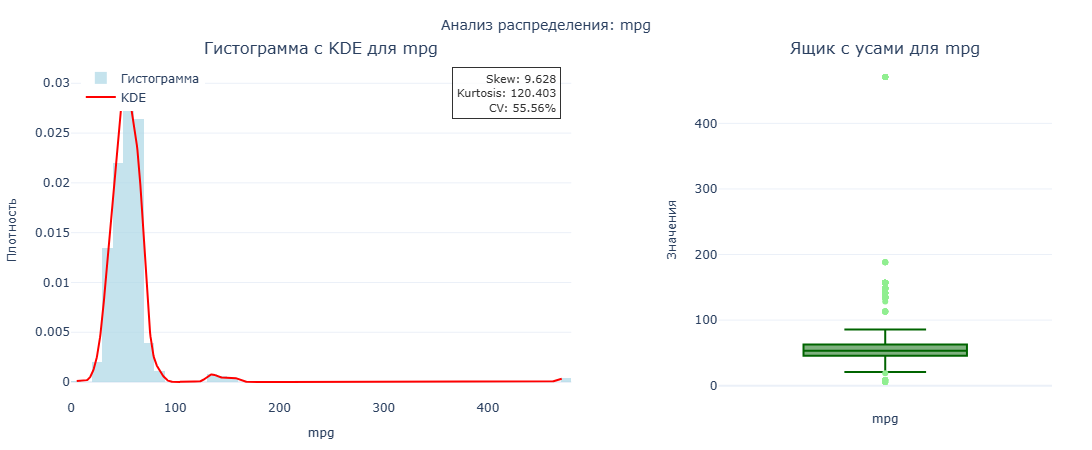

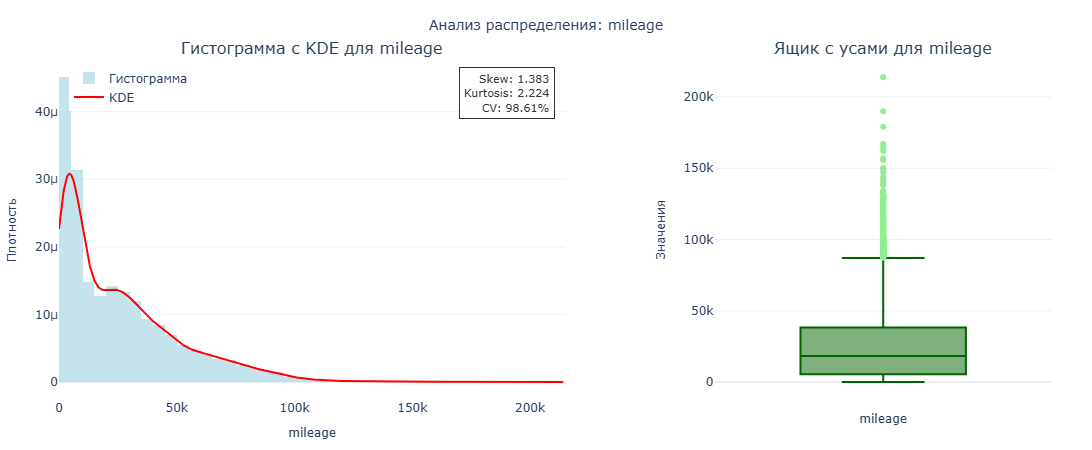

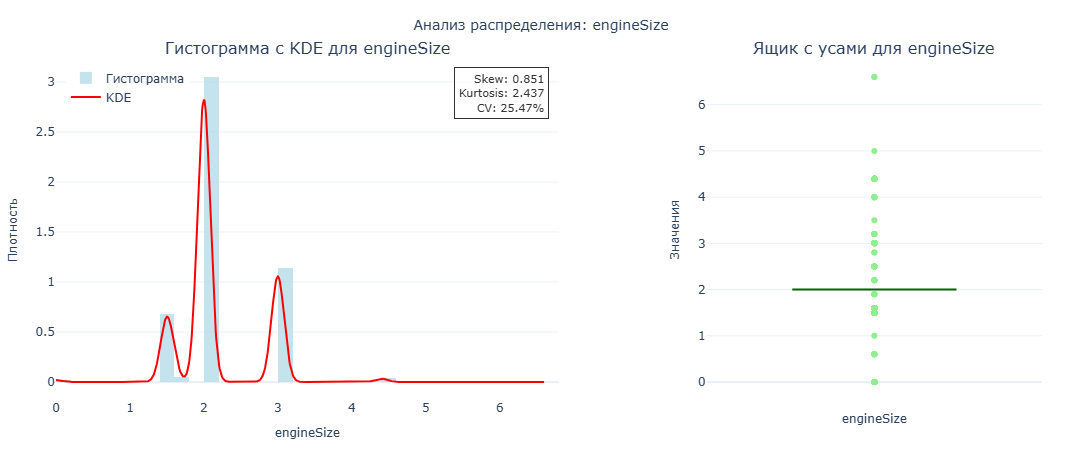

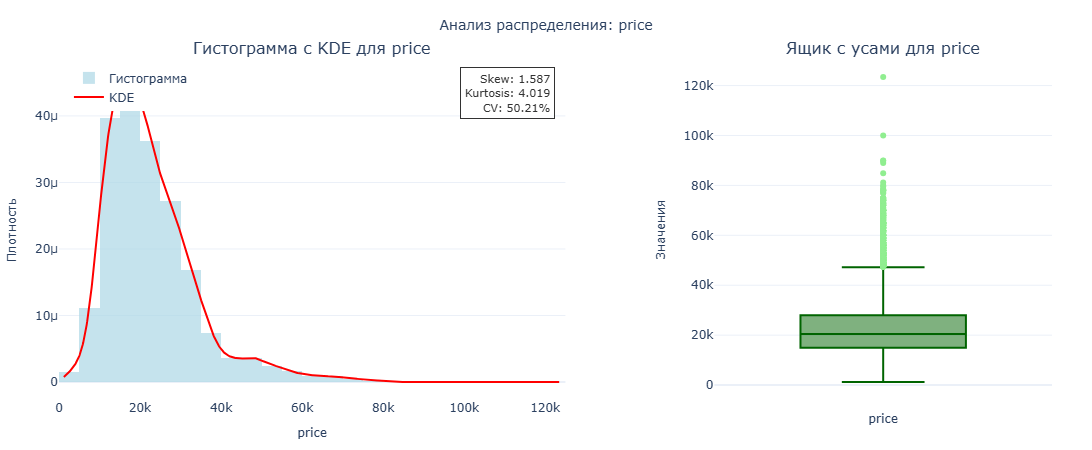

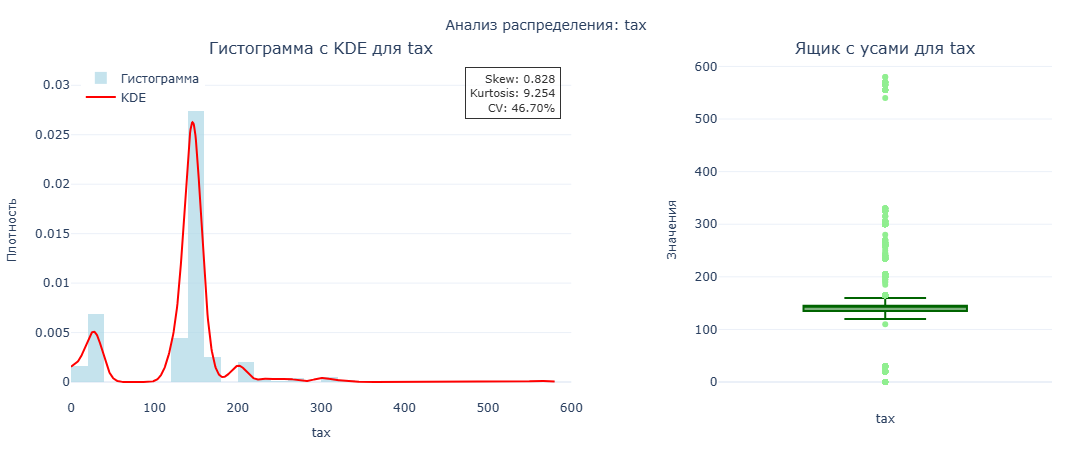

In [15]:
# Создаем графики для каждого числового признака
for col in numeric_cols:
    # Очищаем данные от пропусков
    data_clean = data[col]
    
    stats_row = stats_df[stats_df['Признак'] == col].iloc[0]    
    # Извлекаем статистики
    skew_val = stats_row['Асимметрия']
    kurtosis_val = stats_row['Эксцесс']
    cv_val = stats_row['Коэф. вариации']
    
    # Создаем subplot с 1 строкой и 2 столбцами
    fig = make_subplots(
        rows=1, 
        cols=2,
        subplot_titles=(
            f'Гистограмма с KDE для {col}',
            f'Ящик с усами для {col}'
        ),
        horizontal_spacing=0.15,
        column_widths=[0.6, 0.4]  # Гистограмма шире, чем боксплот
    )
    
    # Гистограмма
    fig.add_trace(
        go.Histogram(
            x=data_clean,
            name='Гистограмма',
            nbinsx=50,
            histnorm='probability density',
            marker_color='lightblue',
            opacity=0.7,
            showlegend=True
        ),
        row=1, col=1
    )
    
    # Кривая плотности (KDE)
    # Генерируем точки для KDE
    kde_x = np.linspace(data_clean.min(), data_clean.max(), 1000)
    kde = stats.gaussian_kde(data_clean)
    kde_y = kde(kde_x)
    
    fig.add_trace(
        go.Scatter(
            x=kde_x,
            y=kde_y,
            mode='lines',
            name='KDE',
            line=dict(color='red', width=2),
            showlegend=True
        ),
        row=1, col=1
    )
    
    # Ящик с усами
    fig.add_trace(
        go.Box(
            y=data_clean,
            name='',
            boxpoints='outliers',  # Показываем только выбросы
            marker_color='lightgreen',
            line_color='darkgreen',
            showlegend=False
        ),
        row=1, col=2
    )
    
    # Добавляем аннотацию со статистиками
    fig.add_annotation(
        xref="x domain",
        yref="y domain",
        x=0.98,  # Правая граница
        y=0.98,  # Верхняя граница
        text=f"Skew: {skew_val:.3f}<br>Kurtosis: {kurtosis_val:.3f}<br>CV: {cv_val:.2%}",
        showarrow=False,
        font=dict(size=11, color="black"),
        align="right",
        bordercolor="black",
        borderwidth=1,
        borderpad=4,
        bgcolor="white",
        opacity=0.8,
        row=1, col=1
    )
    
    # Настраиваем layout
    fig.update_layout(
        title_text=f"Анализ распределения: {col}",
        title_font_size=14,
        title_x=0.5,
        height=450,
        width=950,  # Оптимальная ширина для отображения
        margin=dict(l=40, r=40, t=60, b=40),
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        ),
        template="plotly_white"
    )
    
    # Настраиваем оси для гистограммы
    fig.update_xaxes(
        title_text=col,
        row=1, col=1,
        title_font_size=12
    )
    fig.update_yaxes(
        title_text="Плотность",
        row=1, col=1,
        title_font_size=12
    )
    
    # Настраиваем оси для боксплота
    fig.update_xaxes(
        title_text=col,
        row=1, col=2,
        title_font_size=12
    )
    fig.update_yaxes(
        title_text="Значения",
        row=1, col=2,
        title_font_size=12
    )
    
    # Показываем график
    fig.show()

##  5.	Нормализация / трансформация

In [16]:
def transform_column(col_to_transform, transformer):
    # Проверяем, что колонка существует в данных
    if col_to_transform in data.columns:
        # Очищаем данные от пропусков
        original_data = data[col_to_transform].dropna()
        
        # Применяем логарифмическое преобразование
        transformed_data = transformer(original_data)
        
        # Рассчитываем статистики для оригинальных данных
        original_skew = stats.skew(original_data)
        original_kurtosis = stats.kurtosis(original_data, fisher=True)
        original_mean = original_data.mean()
        original_std = original_data.std()
        original_cv = original_std / original_mean if original_mean != 0 else np.nan
        
        # Рассчитываем статистики для трансформированных данных
        transformed_skew = stats.skew(transformed_data)
        transformed_kurtosis = stats.kurtosis(transformed_data, fisher=True)
        transformed_mean = transformed_data.mean()
        transformed_std = transformed_data.std()
        transformed_cv = transformed_std / transformed_mean if transformed_mean != 0 else np.nan
        
        # Создаем subplot с 2 строками и 2 столбцами
        fig = make_subplots(
            rows=2, 
            cols=2,
            subplot_titles=(
                f'Оригинальное распределение: {col_to_transform}',
                f'Ящик с усами: {col_to_transform}',
                f'Нормализованное распределение: transf({col_to_transform})',
                f'Ящик с усами: transf({col_to_transform})'
            ),
            vertical_spacing=0.12,
            horizontal_spacing=0.15,
            column_widths=[0.6, 0.4]  # Гистограмма шире, чем боксплот
        )
        
        # 1. Гистограмма оригинальных данных (оттенки красного)
        fig.add_trace(
            go.Histogram(
                x=original_data,
                name='Оригинал',
                nbinsx=50,
                histnorm='probability density',
                marker_color='lightcoral',
                opacity=0.7,
                showlegend=False
            ),
            row=1, col=1
        )
        
        # KDE для оригинальных данных (темно-красный)
        kde_x_orig = np.linspace(original_data.min(), original_data.max(), 1000)
        kde_orig = stats.gaussian_kde(original_data)
        kde_y_orig = kde_orig(kde_x_orig)
        
        fig.add_trace(
            go.Scatter(
                x=kde_x_orig,
                y=kde_y_orig,
                mode='lines',
                name='KDE оригинал',
                line=dict(color='darkred', width=2),
                showlegend=False
            ),
            row=1, col=1
        )
        
        # 2. Ящик с усами оригинальных данных (оттенки красного)
        fig.add_trace(
            go.Box(
                y=original_data,
                name='Оригинал',
                boxpoints='outliers',
                marker_color='lightcoral',
                line_color='darkred',
                showlegend=False
            ),
            row=1, col=2
        )
        
        # 3. Гистограмма трансформированных данных (оттенки зеленого)
        fig.add_trace(
            go.Histogram(
                x=transformed_data,
                name='Нормализованное',
                nbinsx=50,
                histnorm='probability density',
                marker_color='lightgreen',
                opacity=0.7,
                showlegend=False
            ),
            row=2, col=1
        )
        
        # KDE для трансформированных данных (темно-зеленый)
        kde_x_trans = np.linspace(transformed_data.min(), transformed_data.max(), 1000)
        kde_trans = stats.gaussian_kde(transformed_data)
        kde_y_trans = kde_trans(kde_x_trans)
        
        fig.add_trace(
            go.Scatter(
                x=kde_x_trans,
                y=kde_y_trans,
                mode='lines',
                name='KDE нормализованного',
                line=dict(color='darkgreen', width=2),
                showlegend=False
            ),
            row=2, col=1
        )
        
        # 4. Ящик с усами трансформированных данных (оттенки зеленого)
        fig.add_trace(
            go.Box(
                y=transformed_data,
                name='Нормализованное',
                boxpoints='outliers',
                marker_color='lightgreen',
                line_color='darkgreen',
                showlegend=False
            ),
            row=2, col=2
        )
        
        # Добавляем аннотации со статистиками
        # Для оригинальных данных (красный фон)
        fig.add_annotation(
            xref="x domain",
            yref="y domain",
            x=0.98,  # Правая граница
            y=0.98,  # Верхняя граница
            text=f"Skew: {original_skew:.3f}<br>Kurtosis: {original_kurtosis:.3f}<br>CV: {original_cv:.2%}",
            showarrow=False,
            font=dict(size=11, color="black"),
            align="right",
            bordercolor="black",
            borderwidth=1,
            borderpad=4,
            bgcolor="rgba(255, 182, 193, 0.9)",  # Светло-красный фон
            opacity=0.9,
            row=1, col=1
        )
        
        # Для трансформированных данных (зеленый фон)
        fig.add_annotation(
            xref="x domain",
            yref="y domain",
            x=0.98,  # Правая граница
            y=0.98,  # Верхняя граница
            text=f"Skew: {transformed_skew:.3f}<br>Kurtosis: {transformed_kurtosis:.3f}<br>CV: {transformed_cv:.2%}",
            showarrow=False,
            font=dict(size=11, color="black"),
            align="right",
            bordercolor="black",
            borderwidth=1,
            borderpad=4,
            bgcolor="rgba(144, 238, 144, 0.9)",  # Светло-зеленый фон
            opacity=0.9,
            row=2, col=1
        )
        
        # Настраиваем layout
        fig.update_layout(
            title_text=f"Сравнение с нормализацией для признака {col_to_transform}",
            title_font_size=14,
            title_x=0.5,
            height=800,
            width=950,
            margin=dict(l=40, r=40, t=80, b=40),
            legend=dict(
                yanchor="top",
                y=0.99,
                xanchor="left",
                x=0.01
            ),
            template="plotly_white"
        )
        
        # Настраиваем оси
        fig.update_xaxes(title_text=col_to_transform, row=1, col=1, title_font_size=12)
        fig.update_yaxes(title_text="Плотность", row=1, col=1, title_font_size=12)
        fig.update_xaxes(title_text=col_to_transform, row=1, col=2, title_font_size=12)
        fig.update_yaxes(title_text="Значения", row=1, col=2, title_font_size=12)
        fig.update_xaxes(title_text=f"transf({col_to_transform})", row=2, col=1, title_font_size=12)
        fig.update_yaxes(title_text="Плотность", row=2, col=1, title_font_size=12)
        fig.update_xaxes(title_text=f"transf({col_to_transform})", row=2, col=2, title_font_size=12)
        fig.update_yaxes(title_text="Значения", row=2, col=2, title_font_size=12)
        
        # Показываем график
        fig.show()
        
        # Таблица сравнения статистик
        stats_comparison = pd.DataFrame({
            'Статистика': ['Skew', 'Kurtosis', 'Коэффициент вариации', 'Среднее', 'Ст. отклонение'],
            'Оригинал': [
                f"{original_skew:.3f}",
                f"{original_kurtosis:.3f}",
                f"{original_cv:.2%}",
                f"{original_mean:.3f}",
                f"{original_std:.3f}"
            ],
            'После transf(x)': [
                f"{transformed_skew:.3f}",
                f"{transformed_kurtosis:.3f}",
                f"{transformed_cv:.2%}",
                f"{transformed_mean:.3f}",
                f"{transformed_std:.3f}"
            ],
            'Изменение %': [
                f"{((transformed_skew - original_skew)/original_skew*100 if original_skew != 0 else 0):.1f}%",
                f"{((transformed_kurtosis - original_kurtosis)/original_kurtosis*100 if original_kurtosis != 0 else 0):.1f}%",
                f"{((transformed_cv - original_cv)/original_cv*100 if original_cv != 0 else 0):.1f}%",
                f"{((transformed_mean - original_mean)/original_mean*100 if original_mean != 0 else 0):.1f}%",
                f"{((transformed_std - original_std)/original_std*100 if original_std != 0 else 0):.1f}%"
            ]
        })
        
        # Выводим таблицу сравнения статистик
        print("\n" + "="*100)
        print("ТАБЛИЦА СРАВНЕНИЯ СТАТИСТИК ДО И ПОСЛЕ НОРМАЛИЗАЦИИ")
        print("="*100)
        display(stats_comparison)
        
    else:
        print(f"Ошибка: Колонка '{col_to_transform}' не найдена в данных.")

In [17]:
transform_column('mpg', lambda original_data: np.log1p(original_data)) # применяем логарифмическую нормализацию


ТАБЛИЦА СРАВНЕНИЯ СТАТИСТИК ДО И ПОСЛЕ НОРМАЛИЗАЦИИ


,Статистика,Оригинал,После transf(x),Изменение %
0,Skew,9.628,1.406,-85.4%
1,Kurtosis,120.403,12.486,-89.6%
2,Коэффициент вариации,55.56%,7.64%,-86.3%
3,Среднее,56.399,3.991,-92.9%
4,Ст. отклонение,31.337,0.305,-99.0%


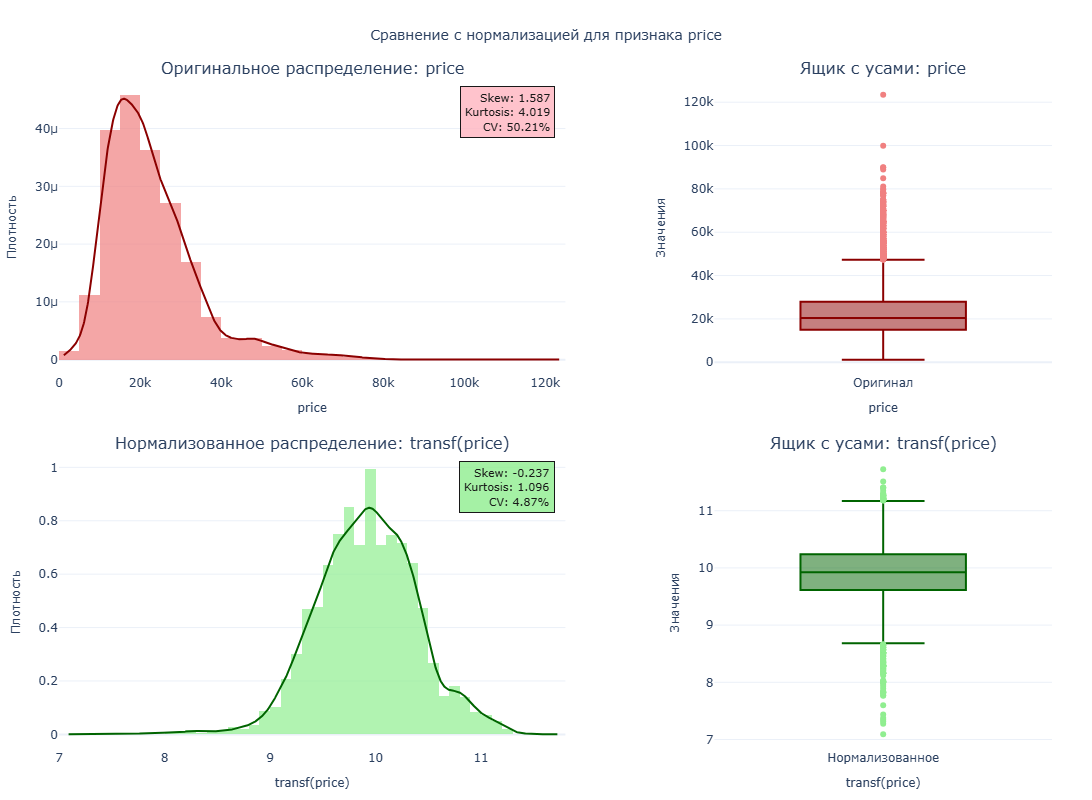


ТАБЛИЦА СРАВНЕНИЯ СТАТИСТИК ДО И ПОСЛЕ НОРМАЛИЗАЦИИ


,Статистика,Оригинал,После transf(x),Изменение %
0,Skew,1.587,-0.237,-114.9%
1,Kurtosis,4.019,1.096,-72.7%
2,Коэффициент вариации,50.21%,4.87%,-90.3%
3,Среднее,22733.409,9.918,-100.0%
4,Ст. отклонение,11415.528,0.483,-100.0%


In [18]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()

# transform_column('price', lambda original_data: scaler.fit_transform(original_data.to_frame()).flatten()) # применяем нормализацию "Z-score"
transform_column('price', lambda original_data: np.log1p(original_data)) # применяем логарифмическую нормализацию

In [19]:
transform_column('tax', lambda original_data: stats.boxcox(original_data)[0]) # применяем нормализацию


ТАБЛИЦА СРАВНЕНИЯ СТАТИСТИК ДО И ПОСЛЕ НОРМАЛИЗАЦИИ


,Статистика,Оригинал,После transf(x),Изменение %
0,Skew,0.828,-1.023,-223.6%
1,Kurtosis,9.254,2.642,-71.5%
2,Коэффициент вариации,46.70%,35.75%,-23.4%
3,Среднее,131.702,27.623,-79.0%
4,Ст. отклонение,61.511,9.876,-83.9%


In [20]:
transform_column('tax', lambda original_data: np.sqrt(original_data)) # применяем нормализацию "Квадратный корень"


ТАБЛИЦА СРАВНЕНИЯ СТАТИСТИК ДО И ПОСЛЕ НОРМАЛИЗАЦИИ


,Статистика,Оригинал,После transf(x),Изменение %
0,Skew,0.828,-1.381,-266.8%
1,Kurtosis,9.254,2.872,-69.0%
2,Коэффициент вариации,46.70%,30.76%,-34.1%
3,Среднее,131.702,10.969,-91.7%
4,Ст. отклонение,61.511,3.374,-94.5%


##  6.	Вывод

Эффективнее всего оказались логарифмические нормализации (первые две). От них очень сильно падают все виды ошибок и данные приводятся к нормаьному виду без увеличения ошибок. Довольно часто применимый способ нормализации.

Мне сложно судить о том как это скажется на обучении нейросетей. Скорее всего после нормализации мы уменьшим шанс переобучения и сделаем нейросень одинаково нормально работающей на большем диапазоне входных данных.